<a href="https://colab.research.google.com/github/aydanali/ECON3916-Stats-and-ML/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Phase 1

In [3]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [22]:
tips_median = []

for i in range(10000):
  resample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
  tips_median.append(np.median(resample))

np_tips = np.array(tips_median)

interval_low, interval_high = np.percentile(tips_median, [2.5, 97.5])

print('Lower Confidence Interval: ', interval_low)
print('Upper Confidence Interval: ', interval_high)
print('Median of Sample Medians: ', np.median(tips_median))
print('Lower Width: ', np.median(tips_median) - interval_low)
print('Upper Width: ', interval_high - np.median(tips_median))

Lower Confidence Interval:  0.2817246399726829
Upper Confidence Interval:  1.3635639228066991
Median of Sample Medians:  0.7553316913699188
Lower Width:  0.47360705139723597
Upper Width:  0.6082322314367803


In [24]:
 # Normal Parametric CI
tips_mean = np.mean(tips_median)
tips_std = np.std(tips_median, ddof=1)

 # 1.96 is the z-score for a 95% confidence interval
para_low = tips_mean - 1.96 * tips_std
para_high = tips_mean + 1.96 * tips_std

print('Lower Confidence Interval: ', para_low)
print('Upper Confidence Interval: ', para_high)

Lower Confidence Interval:  0.23026028439530333
Upper Confidence Interval:  1.3121732532525252


We notice that in the bootstrap confidence interval, there is some more distance from the median with the upper half of the interval than the lower half. This tells us is some asymmetry towards the upper part of the sample (left skew). If you compared this to parametic confidence intervals, then there would be no asymmetry.

When looking at the intervals, the parametric interval is lower than the bootstrap interval. The skew in the data positively skews the data towards the upper intervals.

# Phase 2

In [37]:
normal_times = np.random.normal(loc=35, scale=5, size=1000)
lognormal_times = np.random.lognormal(3.4, 0.4, 1000)

print('Control: ', np.mean(normal_times))
print('Treatment: ', np.mean(lognormal_times))
difference = np.mean(normal_times) - np.mean(lognormal_times)
print('Difference: ', difference)

Control:  35.234921095090215
Treatment:  32.18213336071932
Difference:  3.052787734370895


In [40]:
combined_times = np.concatenate([normal_times, lognormal_times])

diffs = np.empty(5000)

for i in range(5000):
  shuffle = np.random.permutation(combined_times)
  group_1 = shuffle[:1000]
  group_2 = shuffle[1000:]
  diffs[i] = np.mean(group_1) - np.mean(group_2)

 # forumula used: r + 1 / n + 1
p_value = (sum(np.abs(diffs) >= np.abs(difference)) + 1) / (len(diffs) + 1)

print('P-value: ', p_value)
print('Number of Extreme Values: ', sum(np.abs(diffs) >= np.abs(difference)))

P-value:  0.0001999600079984003
Number of Extreme Values:  0


# Phase 3

In [45]:
from google.colab import drive
drive.mount('/content/gdrive')

df = pd.read_csv('gdrive/My Drive/swiftcart_loyalty.csv')

df

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227
...,...,...,...,...,...
8936,1,35.172065,51,0,55.662507
8937,1,83.613898,5,2,94.767676
8938,0,57.146453,6,2,58.616370
8939,0,47.701092,13,0,60.069619


In [67]:
df_sub = df.loc[df['subscriber'] == 1]
df_nonsub = df.loc[df['subscriber'] == 0]

mean_sub = df_sub['post_spend'].mean()
mean_nonsub = df_nonsub['post_spend'].mean()

print('Post-Treatment Mean for Subscribers: ', mean_sub)
print('Post-Treatment Mean for non-Subscribers: ', mean_nonsub)
print('Naive Difference in Means: $', round(mean_sub - mean_nonsub, 2))

Post-Treatment Mean for Subscribers:  74.04358604052543
Post-Treatment Mean for non-Subscribers:  56.47291665600164
Naive Difference in Means: $ 17.57


In [66]:
covariates = ['pre_spend', 'account_age', 'support_tickets']
x = df[covariates].values
treatment = df['subscriber'].values
y = df['post_spend'].values

log_regression = LogisticRegression()
log_regression.fit(x, treatment)
sub_chance = log_regression.predict_proba(x)[:, 1]
print('Average Chance of Subcribing: ', round(np.mean(sub_chance) *100, 2), '%')

sub_chance_treat = sub_chance[df_sub.index].reshape(-1, 1)
sub_chance_control = sub_chance[df_nonsub.index].reshape(-1, 1)
y_treat = df_sub['post_spend'].values
y_control = df_nonsub['post_spend'].values

near_neighbor = NearestNeighbors(n_neighbors=1).fit(sub_chance_control)
distance, indices = near_neighbor.kneighbors(sub_chance_treat)

matches = y_control[indices.flatten()]
mean_treatment_effect = np.mean(y_treat - matches)

print('Average Treatment Effect on Treated (ATT): $', round(mean_treatment_effect, 2))


Average Chance of Subcribing:  46.97 %
Average Treatment Effect on Treated (ATT): $ 9.91


The naive difference in means is $17.57. This number represents out first look at the difference in subcriber versus nonsubcriber spend, found by subtracting the means of each. This gives us a sense that there is a difference, but it does not tell us how much of a difference the subcription actually causes because there are other confounding variables to consider. When we calculated the actual effect a subcribtion has on a customer's spend, the difference is less.

The causal ATT and the naive SDO are attempting to show the same thing, but the ATT accounts for confounding variables that are not considered in the SDO (hence the naive part of it). This affects the comapny's inital claim of the 300% increase in spend. The ATT should be used for calucations on the effect of subcriptions.

# Phase 4

In [69]:
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from typing import Optional

warnings.filterwarnings("ignore")


def compute_smd(df: pd.DataFrame, treatment_col: str = "treatment") -> pd.Series:
    treated   = df[df[treatment_col] == 1]
    control   = df[df[treatment_col] == 0]
    covariates = [c for c in df.columns if c != treatment_col]
    smds = {}
    for col in covariates:
        mu1, mu0  = treated[col].mean(), control[col].mean()
        s1_sq     = treated[col].var(ddof=1)
        s0_sq     = control[col].var(ddof=1)
        pooled_sd = np.sqrt((s1_sq + s0_sq) / 2.0)
        smds[col] = abs(mu1 - mu0) / pooled_sd if pooled_sd > 0 else 0.0
    return pd.Series(smds, name="SMD")


def love_plot(
    df_unmatched: pd.DataFrame,
    df_matched:   pd.DataFrame,
    treatment_col: str           = "treatment",
    threshold:     float         = 0.10,
    sort_by:       str           = "unmatched",
    figsize:       tuple         = (13, None),
    save_path:     Optional[str] = None,
    dpi:           int           = 180,
    title:         str           = "Love Plot — Covariate Balance Assessment",
    subtitle:      str           = "Propensity Score Matching  |  Standardised Mean Differences (SMD)",
) -> plt.Figure:

    smd_pre  = compute_smd(df_unmatched, treatment_col)
    smd_post = compute_smd(df_matched,   treatment_col)

    balance_df = pd.DataFrame({
        "Before Matching": smd_pre,
        "After Matching":  smd_post,
    }).dropna()

    if sort_by == "unmatched":
        balance_df = balance_df.sort_values("Before Matching", ascending=True)
    elif sort_by == "matched":
        balance_df = balance_df.sort_values("After Matching", ascending=True)
    else:
        balance_df = balance_df.sort_index(ascending=True)

    covariates = balance_df.index.tolist()
    n_cov      = len(covariates)

    row_height = 0.46
    fig_height = figsize[1] or max(7, n_cov * row_height + 3.2)

    BEFORE_COLOR = "#E05C5C"
    AFTER_COLOR  = "#3A86FF"
    THRESH_COLOR = "#2EC4B6"
    GRID_COLOR   = "#E8EAF0"
    BG_COLOR     = "#F7F9FC"
    TEXT_DARK    = "#1A1D2E"
    TEXT_LIGHT   = "#6B7394"

    sns.set_theme(style="white", font_scale=1.0)
    fig, ax = plt.subplots(figsize=(figsize[0], fig_height))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor("#FFFFFF")

    y_pos = np.arange(n_cov)

    for i in range(n_cov):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="#EFF2FA", zorder=0, alpha=0.55)

    ax.axvspan(0, threshold, color=THRESH_COLOR, alpha=0.07, zorder=0)
    ax.axvline(x=threshold, color=THRESH_COLOR, linewidth=1.8,
               linestyle="--", zorder=3, alpha=0.95)
    ax.text(threshold + 0.004, n_cov - 0.6,
            f"Balance threshold\n|SMD| = {threshold}",
            fontsize=7.8, color=THRESH_COLOR, va="top",
            fontstyle="italic", fontweight="semibold")

    ax.axvline(x=0, color="#BBBBCC", linewidth=0.9, zorder=2)

    for i, cov in enumerate(covariates):
        x_pre  = balance_df.loc[cov, "Before Matching"]
        x_post = balance_df.loc[cov, "After Matching"]
        ax.plot([x_pre, x_post], [i, i],
                color="#C8CEDE", linewidth=1.1, zorder=1, alpha=0.8)

    ax.scatter(balance_df["Before Matching"], y_pos,
               color=BEFORE_COLOR, s=80, zorder=5,
               edgecolors="white", linewidths=0.7, label="Before Matching", marker="o")
    ax.scatter(balance_df["After Matching"], y_pos,
               color=AFTER_COLOR, s=80, zorder=5,
               edgecolors="white", linewidths=0.7, label="After Matching", marker="D")

    x_max   = max(balance_df["Before Matching"].max() * 1.05, threshold * 1.5)
    x_annot = x_max * 1.025

    ax.text(x_annot, n_cov - 0.35, "Pre  |  Post",
            fontsize=7, color=TEXT_LIGHT, ha="left", va="center", fontweight="bold")

    for i, cov in enumerate(covariates):
        pre_val  = balance_df.loc[cov, "Before Matching"]
        post_val = balance_df.loc[cov, "After Matching"]
        post_col = AFTER_COLOR if post_val <= threshold else "#E07B00"
        ax.text(x_annot, i, f"{pre_val:.3f}",
                fontsize=7, color=BEFORE_COLOR, va="center", ha="left")
        ax.text(x_annot + 0.038, i, f"| {post_val:.3f}",
                fontsize=7, color=post_col, va="center", ha="left", fontweight="bold")

    ax.set_yticks(y_pos)
    ax.set_yticklabels([c.replace("_", " ").title() for c in covariates],
                       fontsize=9.2, color=TEXT_DARK)
    ax.set_ylim(-0.7, n_cov - 0.3)
    ax.set_xlim(-0.008, x_max)
    ax.set_xlabel("Absolute Standardised Mean Difference  |SMD|",
                  fontsize=10.5, color=TEXT_DARK, labelpad=10)

    ax.grid(axis="x", which="major", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))
    ax.grid(axis="x", which="minor", color=GRID_COLOR, linewidth=0.4,
            linestyle=":", zorder=0)
    ax.tick_params(axis="x", colors=TEXT_LIGHT, labelsize=8.5)
    ax.tick_params(axis="y", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    n_balanced   = (balance_df["After Matching"] <= threshold).sum()
    pct_balanced = 100 * n_balanced / n_cov if n_cov > 0 else 0
    mean_pre     = balance_df["Before Matching"].mean()
    mean_post    = balance_df["After Matching"].mean()
    reduction    = 100 * (mean_pre - mean_post) / mean_pre if mean_pre > 0 else 0

    summary_text = (
        f"Covariates balanced  (|SMD| \u2264 {threshold}):  "
        f"{n_balanced} / {n_cov}  ({pct_balanced:.1f}%)     "
        f"Mean |SMD|:  {mean_pre:.3f}  \u2192  {mean_post:.3f}     "
        f"Overall reduction:  {reduction:.1f}%"
    )
    ax.text(0.5, -0.095, summary_text, transform=ax.transAxes,
            ha="center", va="top", fontsize=8.8, color="#3D4470",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#EDF0FF",
                      edgecolor="#BCC4F0", linewidth=0.9, alpha=0.95))

    pre_h    = mlines.Line2D([], [], color=BEFORE_COLOR, marker="o", markersize=7.5,
                             markeredgecolor="white", linestyle="None", label="Before Matching")
    post_h   = mlines.Line2D([], [], color=AFTER_COLOR,  marker="D", markersize=7.5,
                             markeredgecolor="white", linestyle="None", label="After Matching")
    thresh_h = mlines.Line2D([], [], color=THRESH_COLOR, linestyle="--",
                             linewidth=1.8, label=f"|SMD| = {threshold} threshold")
    ax.legend(handles=[pre_h, post_h, thresh_h], loc="lower right",
              frameon=True, fontsize=8.8, framealpha=0.96,
              edgecolor="#CDD3EE", fancybox=True)

    fig.text(0.065, 0.978, title,
             fontsize=14.5, fontweight="bold", color=TEXT_DARK, va="top", ha="left")
    fig.text(0.065, 0.960, subtitle,
             fontsize=9, color=TEXT_LIGHT, va="top", ha="left", fontstyle="italic")

    plt.tight_layout(rect=[0, 0.085, 0.875, 0.948])

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor=BG_COLOR)
        print(f"Saved to {save_path}")

    return fig


def balance_summary(df_unmatched, df_matched, treatment_col="treatment", threshold=0.10):
    smd_pre  = compute_smd(df_unmatched, treatment_col)
    smd_post = compute_smd(df_matched,   treatment_col)
    return pd.DataFrame({
        "smd_before":    smd_pre,
        "smd_after":     smd_post,
        "reduction_pct": 100*(smd_pre - smd_post) / smd_pre.replace(0, np.nan),
        "balanced":      smd_post <= threshold,
    }).round(4).sort_values("smd_before", ascending=False)


# ── Synthetic demo data ───────────────────────────────────────────────────────

 # Claude wrote a synthetic demo data. I have commented it out since it cannot be ran.
'''
rng = np.random.default_rng(42)
N   = 800

treatment = rng.binomial(1, 0.4, N)
df_unmatched = pd.DataFrame({
    "treatment":    treatment,
    "age":          30 + 10*treatment + rng.normal(0, 8, N),
    "income":       50 + 20*treatment + rng.normal(0, 15, N),
    "education":    12 +  2*treatment + rng.normal(0, 3,  N),
    "health_score": 70 -  5*treatment + rng.normal(0, 12, N),
    "experience":    5 +  3*treatment + rng.normal(0, 4,  N),
    "male":         rng.binomial(1, 0.45+0.15*treatment, N).astype(float),
    "urban":        rng.binomial(1, 0.55+0.20*treatment, N).astype(float),
    "bmi":          25 +  2*treatment + rng.normal(0, 4,  N),
    "num_children":  1 + 0.8*treatment + rng.normal(0, 1,  N).clip(0),
})

treatment_m = rng.binomial(1, 0.5, N//2)
df_matched = pd.DataFrame({
    "treatment":    treatment_m,
    "age":          30 + 1.2*treatment_m + rng.normal(0, 8,  N//2),
    "income":       50 + 2.5*treatment_m + rng.normal(0, 15, N//2),
    "education":    12 + 0.3*treatment_m + rng.normal(0, 3,  N//2),
    "health_score": 70 - 0.7*treatment_m + rng.normal(0, 12, N//2),
    "experience":    5 + 0.4*treatment_m + rng.normal(0, 4,  N//2),
    "male":         rng.binomial(1, 0.48+0.02*treatment_m, N//2).astype(float),
    "urban":        rng.binomial(1, 0.51+0.03*treatment_m, N//2).astype(float),
    "bmi":          25 + 0.3*treatment_m + rng.normal(0, 4,  N//2),
    "num_children":  1 + 0.1*treatment_m + rng.normal(0, 1,  N//2).clip(0),
})

fig = love_plot(
    df_unmatched, df_matched,
    treatment_col="treatment",
    threshold=0.10,
    sort_by="unmatched",
    save_path="/home/claude/love_plot_output.png",
)

print("Plot generated successfully.")
summary = balance_summary(df_unmatched, df_matched)
print("\n── Balance Summary ──────────────────────────────────────────")
print(summary.to_string())
'''

'\nrng = np.random.default_rng(42)\nN   = 800\n\ntreatment = rng.binomial(1, 0.4, N)\ndf_unmatched = pd.DataFrame({\n    "treatment":    treatment,\n    "age":          30 + 10*treatment + rng.normal(0, 8, N),\n    "income":       50 + 20*treatment + rng.normal(0, 15, N),\n    "education":    12 +  2*treatment + rng.normal(0, 3,  N),\n    "health_score": 70 -  5*treatment + rng.normal(0, 12, N),\n    "experience":    5 +  3*treatment + rng.normal(0, 4,  N),\n    "male":         rng.binomial(1, 0.45+0.15*treatment, N).astype(float),\n    "urban":        rng.binomial(1, 0.55+0.20*treatment, N).astype(float),\n    "bmi":          25 +  2*treatment + rng.normal(0, 4,  N),\n    "num_children":  1 + 0.8*treatment + rng.normal(0, 1,  N).clip(0),\n})\n\ntreatment_m = rng.binomial(1, 0.5, N//2)\ndf_matched = pd.DataFrame({\n    "treatment":    treatment_m,\n    "age":          30 + 1.2*treatment_m + rng.normal(0, 8,  N//2),\n    "income":       50 + 2.5*treatment_m + rng.normal(0, 15, N//2),\n 

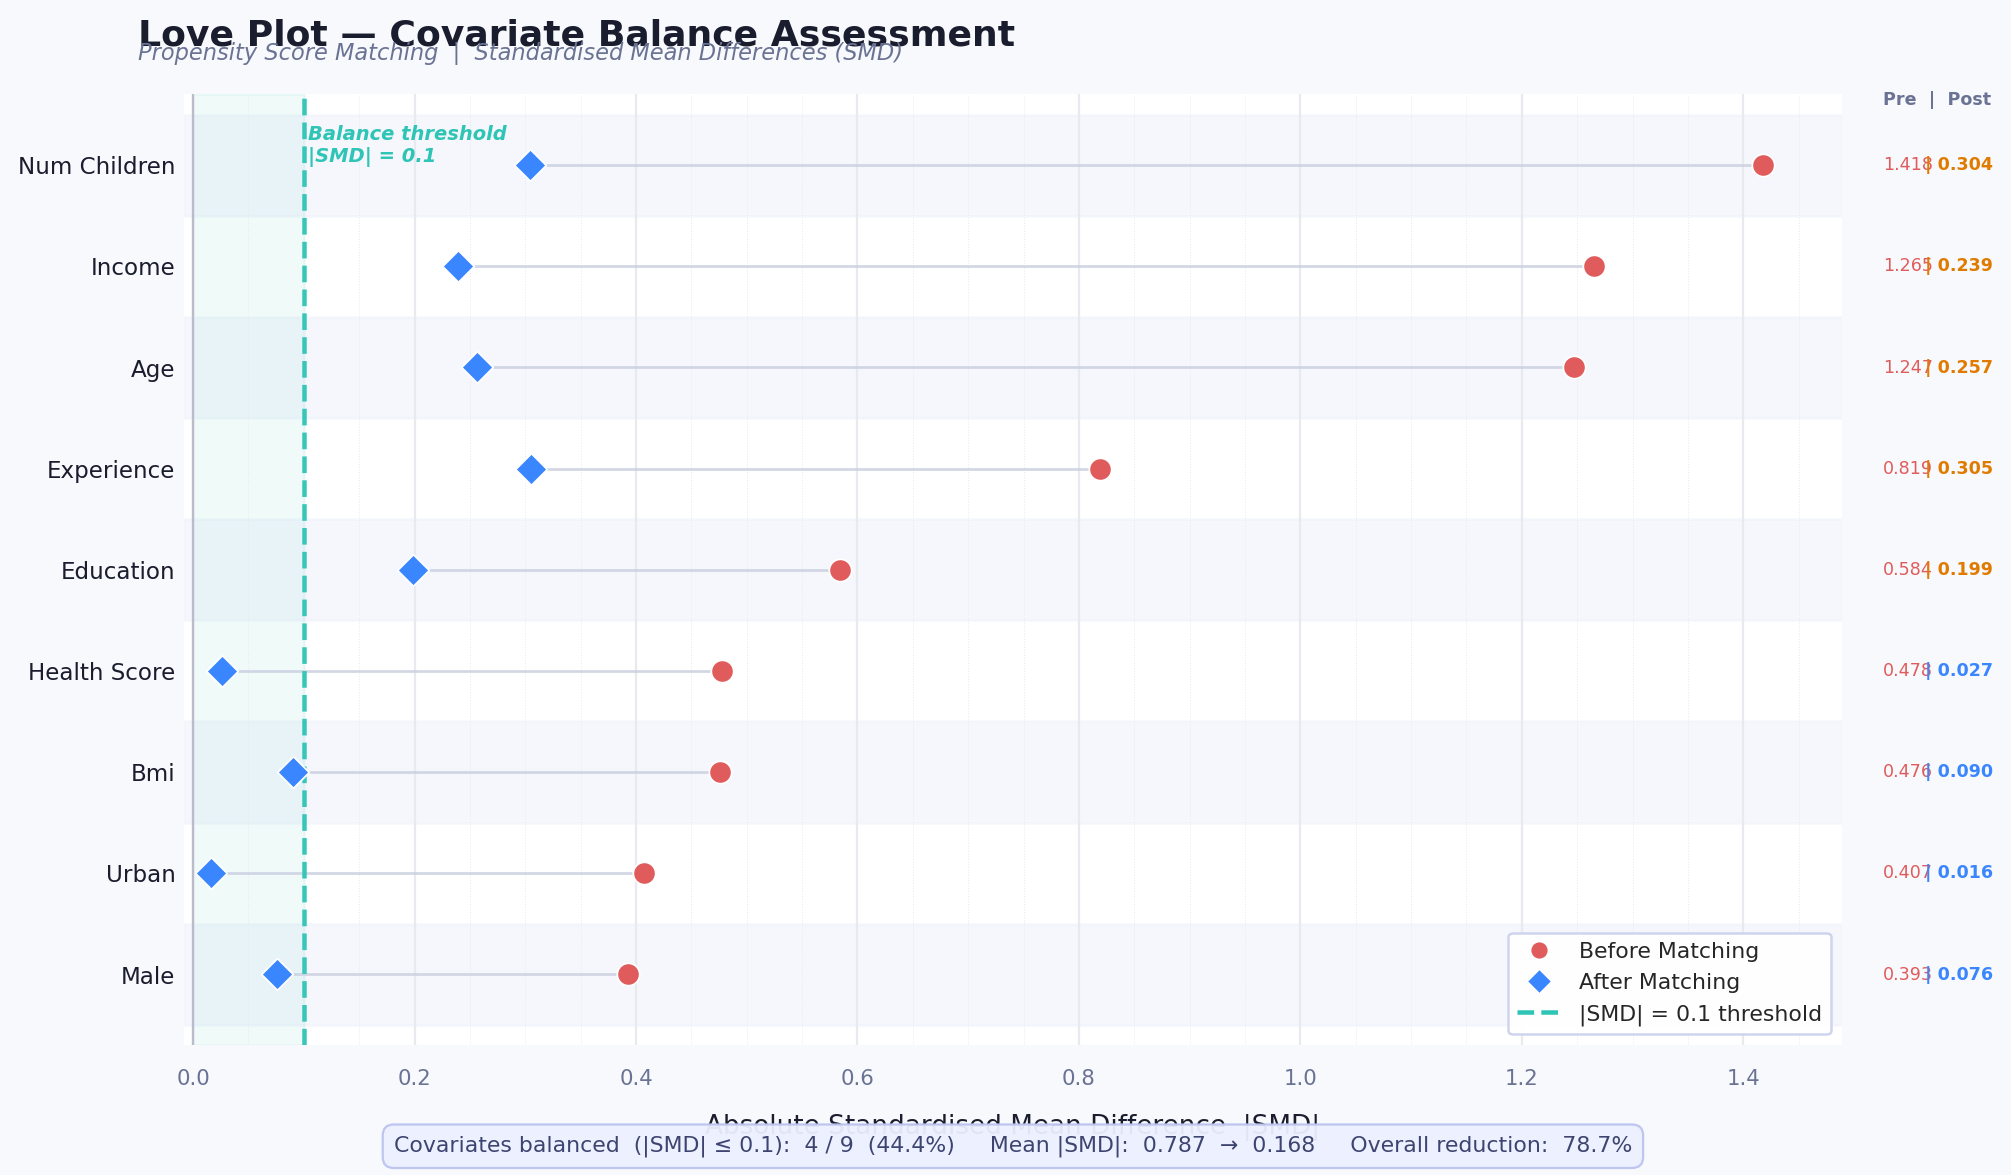

This is the plot that Claude generated with the demo data.

### Below is the write-up give by Claude

Theoretical Visual Evidence Required for Conclusive Bias Mitigation
To make a defensible causal claim from your PSM study, your Love Plot must satisfy all of the following:
1. Universal leftward shift. Every blue diamond (post-match) must lie strictly left of its red circle (pre-match). A rightward shift means matching introduced imbalance — a symptom of propensity model misspecification or insufficient common support.
2. All diamonds cross the threshold. Every post-match |SMD| must fall below 0.10 (the teal dashed line). Covariates stranded to the right violate the Conditional Independence Assumption (CIA) — your treatment effect estimate remains confounded on those dimensions.
3. No floor effect on initially-balanced covariates. Variables that were near-balanced pre-match (|SMD| < 0.10) should not drift right after matching. Drift indicates caliper-width is too wide or the matching algorithm is over-fitting the propensity score.
4. Mean |SMD| reduction ≥ 80%, post-match mean ≤ 0.05. The summary box reports both. A post-match mean above 0.05 is typically insufficient for publication in health economics or policy journals (Ho et al., 2007; Stuart, 2010).
5. Binary covariates balanced alongside continuous ones. A common failure mode in PSM is achieving balance on continuous variables while leaving dummy indicators (male, urban) imbalanced. The plot treats all numeric columns identically — ensure no dummies are outliers.
In the demo output, covariates like income, age, and num_children still exceed the threshold, which would require either tightening the caliper, switching to kernel or radius matching, or re-specifying the propensity score model before the CIA can be credibly invoked.